In [20]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore') 

In [25]:
# loading the dataset 
data = pd.read_csv('../dataset/Tourism_Game_Park_Datasets.csv')
# Display the first few rows of the dataset
data.head()

,RecordID,Park,Animal,Visitors,TempC,RainfallMM,Season,Detected,ModelScore,VisitDate
0,1,Kibale,Elephant,32,30.6,125.0,Dry,Yes,0.86,2024-12-12
1,2,Kibale,Leopard,64,28,16.0,Dry,Yes,0.61,2024-09-15
2,3,Lake Mburo,Elephant,307,21.4,279.0,Wet,Yes,0.72,2024-05-22
3,4,Mgahinga,Chimpanzee,23,30.9,81.0,Wet,No,0.64,2024-04-20
4,5,Mgahinga,Gorilla,72,19.6,49.0,Wet,No,0.80,2024-01-23


In [26]:
# Check for missing values
data.isnull().sum()

RecordID      0
Park          0
Animal        1
Visitors      0
TempC         0
RainfallMM    1
Season        0
Detected      0
ModelScore    1
VisitDate     0
dtype: int64

In [27]:
#removing the missing values
data = data.dropna()

In [28]:
#cheacking whether the missing values have been removed or not
data.isnull().sum()

RecordID      0
Park          0
Animal        0
Visitors      0
TempC         0
RainfallMM    0
Season        0
Detected      0
ModelScore    0
VisitDate     0
dtype: int64

In [30]:
# checking for duplicate rows
data.duplicated().sum()

np.int64(0)

In [31]:
#  checking for wrong format of data in the dataset
# checking for wrong data type in the dataset
data.dtypes

RecordID          str
Park              str
Animal            str
Visitors          str
TempC             str
RainfallMM    float64
Season            str
Detected          str
ModelScore    float64
VisitDate         str
dtype: object

In [35]:
# fixingthe wrong data type in the dataset and wrong format of data in the dataset
#Convert Visitors from string to numeric
data['Visitors'] = pd.to_numeric(data['Visitors'], errors='coerce') 
#Convert TempC from string to numeric
data['TempC'] = pd.to_numeric(data['TempC'], errors='coerce')
#Convert VisitDate from string to date format
data['VisitDate'] = pd.to_datetime(data['VisitDate'], errors='coerce')

In [36]:
#Check the data types again
data.dtypes

RecordID                 str
Park                     str
Animal                   str
Visitors             float64
TempC                float64
RainfallMM           float64
Season                   str
Detected                 str
ModelScore           float64
VisitDate     datetime64[us]
dtype: object

In [37]:
#dropping the RecordID column as it does not contain useful information.
data = data.drop('RecordID', axis=1)

In [38]:
# Summary statistics of the dataset
data.describe()

,Visitors,TempC,RainfallMM,ModelScore,VisitDate
count,1489.000000,1488.000000,1490.000000,1490.000000,1488
mean,259.060443,26.263374,151.920805,0.747329,2024-07-07 02:26:07.741935
min,20.000000,18.000000,0.000000,0.500000,2024-01-01 00:00:00
25%,136.000000,21.975000,72.000000,0.630000,2024-04-01 18:00:00
50%,262.000000,26.200000,153.000000,0.740000,2024-07-13 00:00:00
75%,381.000000,30.300000,227.000000,0.860000,2024-10-10 00:00:00
max,500.000000,34.900000,300.000000,1.500000,2024-12-31 00:00:00
std,139.212022,4.884774,86.447073,0.138208,NaN


In [39]:
#checking  for have 2 missing temperatures.
data['TempC'].isnull().sum()

np.int64(2)

In [40]:
#checking for which rows have missing temperatures
data[data['TempC'].isnull()]

,Park,Animal,Visitors,TempC,RainfallMM,Season,Detected,ModelScore,VisitDate
40,Kibale,Gorilla,102.0,NaN,282.0,Wet,Yes,0.55,2024-12-19
180,Queen Elizabeth,Elephant,171.0,NaN,51.0,Dry,No,0.93,2024-11-12


In [41]:
# Fill missing TempC values with the average temperature
data['TempC'] = data['TempC'].fillna(data['TempC'].mean())

In [42]:
# ckeacking for missing values after filling
data['TempC'].isnull().sum()

np.int64(0)

In [43]:
#checking for all missing values after filling the missing values
data.isnull().sum()

Park          0
Animal        0
Visitors      1
TempC         0
RainfallMM    0
Season        0
Detected      0
ModelScore    0
VisitDate     2
dtype: int64

In [45]:
#Fix missing Visitors
data['Visitors'] = data['Visitors'].fillna(data['Visitors'].mean())
#Fix missing VisitDate
data[data['VisitDate'].isnull()]   

,Park,Animal,Visitors,TempC,RainfallMM,Season,Detected,ModelScore,VisitDate
140,Kidepo,Chimpanzee,95.0,31.4,1.0,Wet,Yes,0.98,NaT
160,Murchison Falls,Elephant,124.0,23.1,108.0,Dry,No,0.64,NaT


In [48]:
#sorting the by date
data = data.sort_values('VisitDate')
#Then fill missing dates
data['VisitDate'] = data['VisitDate'].ffill() 

In [49]:
#checking again after filling missing values
data['VisitDate'].isnull().sum()

np.int64(0)

In [50]:
#overall checking for missing values after filling the missing values
data.isnull().sum()

Park          0
Animal        0
Visitors      0
TempC         0
RainfallMM    0
Season        0
Detected      0
ModelScore    0
VisitDate     0
dtype: int64

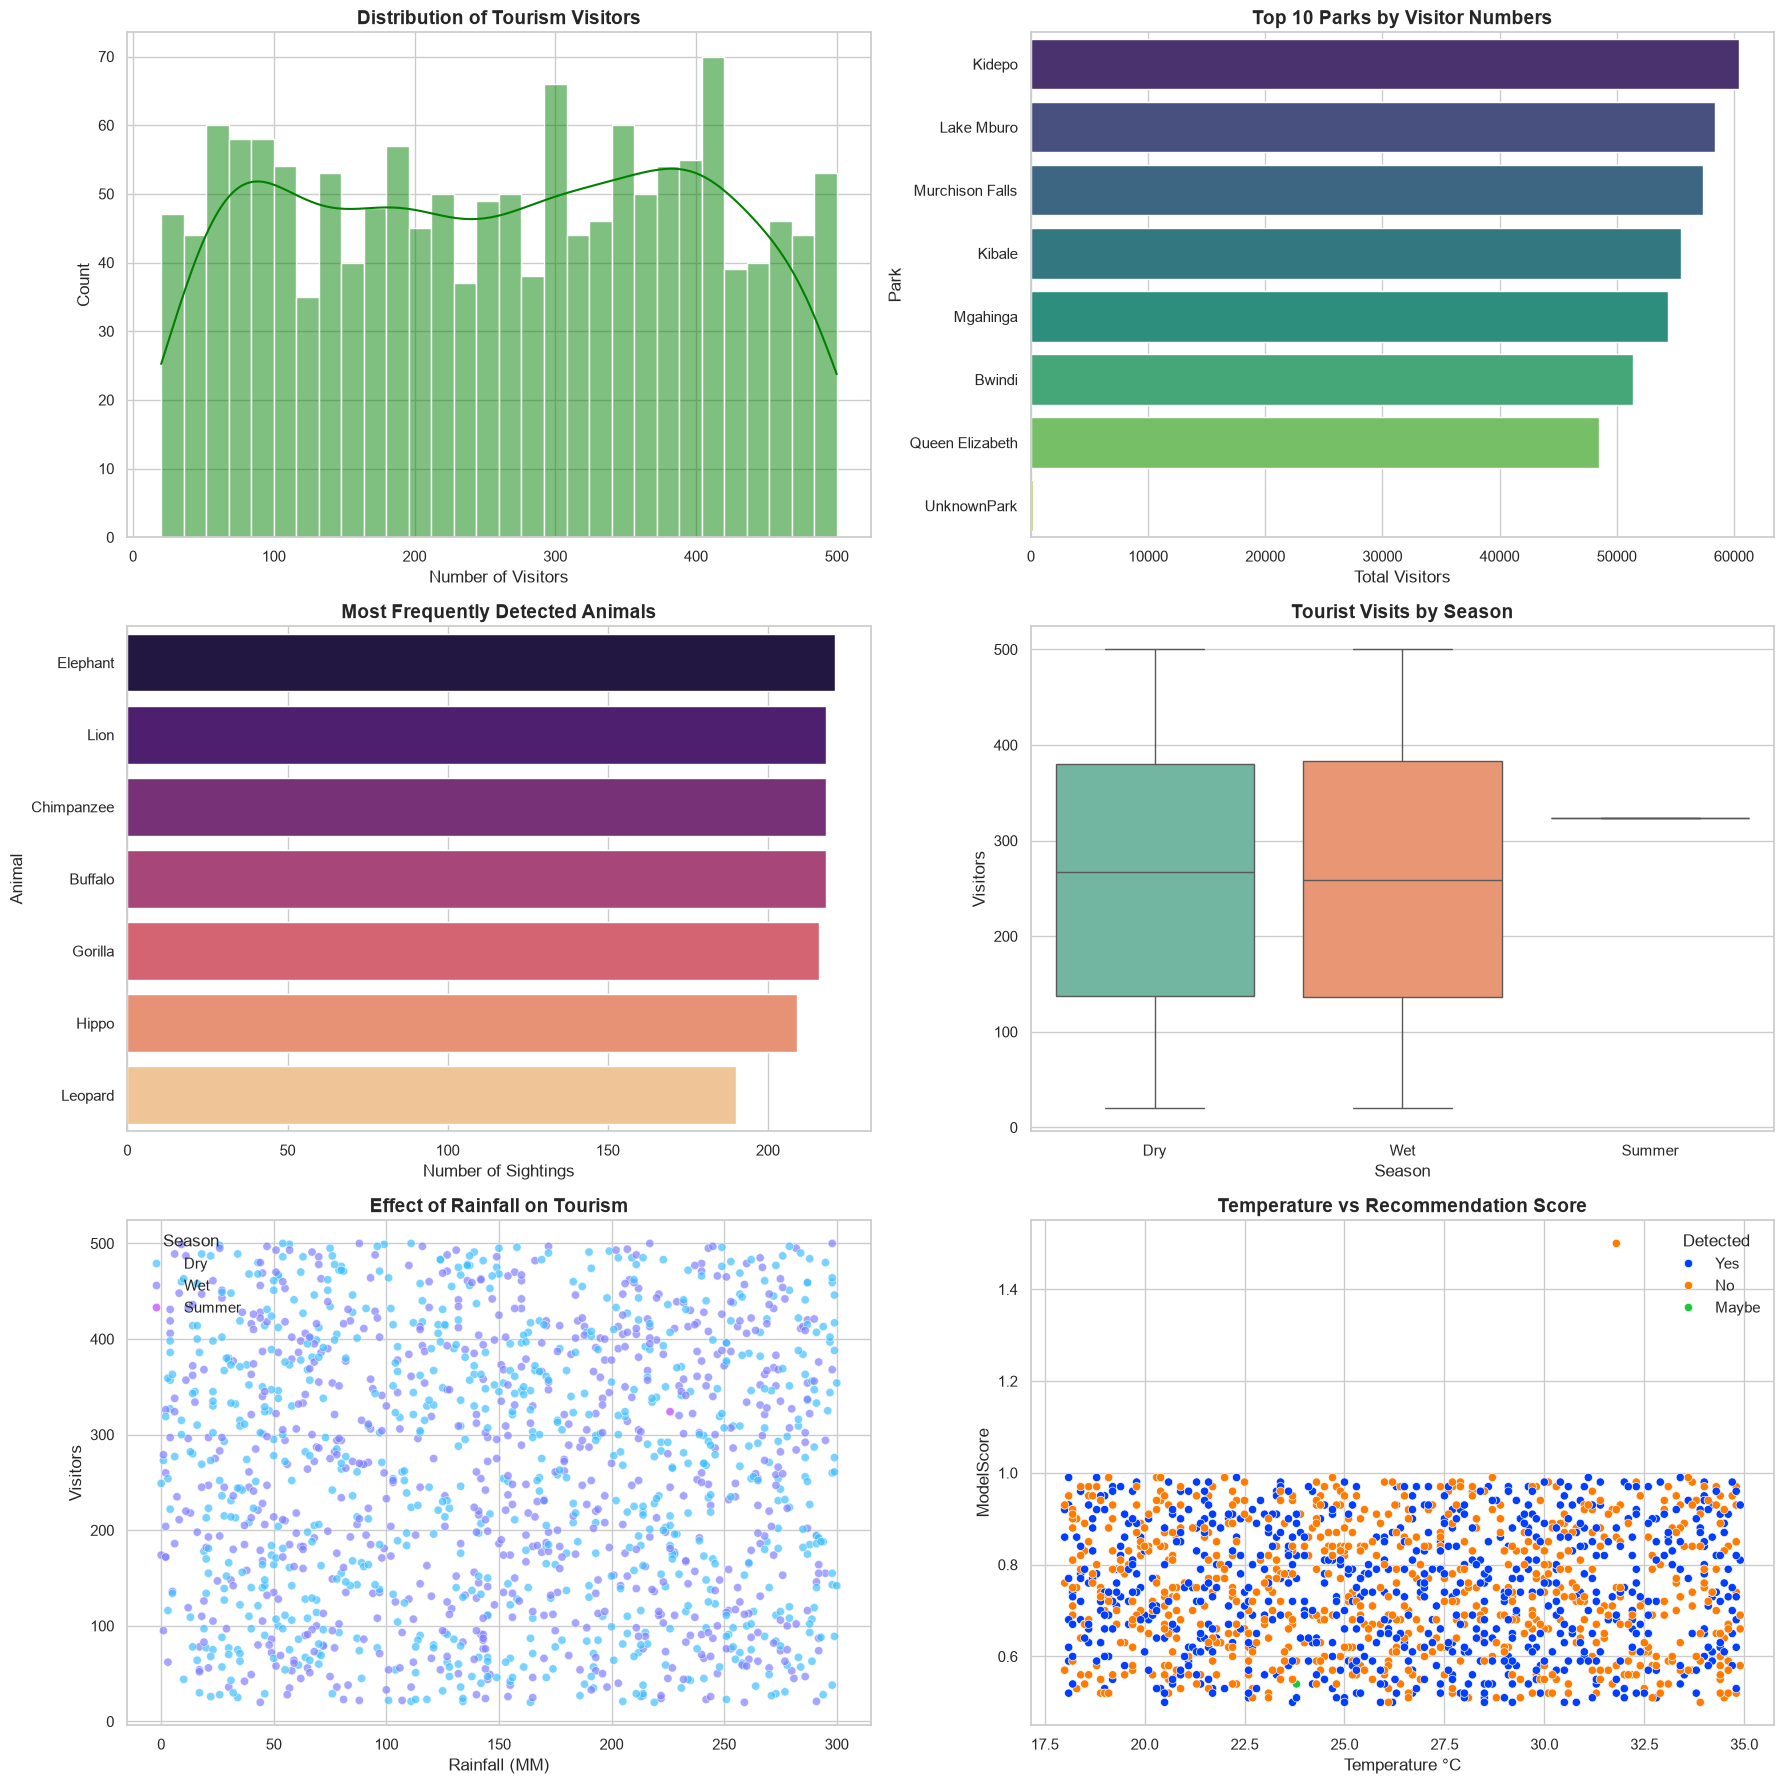

In [52]:
# =====================================
# AI Wildlife Tourism Data Visualization
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Better visualization style
sns.set_theme(style="whitegrid")


# Create multiple plots
fig, axes = plt.subplots(3, 2, figsize=(18, 18))


# -------------------------------------
# 1. Visitors Distribution
# -------------------------------------

sns.histplot(
    data=data,
    x="Visitors",
    bins=30,
    kde=True,
    color="green",
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Distribution of Tourism Visitors",
    fontsize=14,
    fontweight="bold"
)

axes[0,0].set_xlabel("Number of Visitors")


# -------------------------------------
# 2. Top Parks by Visitors
# -------------------------------------

park_visits = (
    data.groupby("Park")["Visitors"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


sns.barplot(
    x=park_visits.values,
    y=park_visits.index,
    palette="viridis",
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Top 10 Parks by Visitor Numbers",
    fontsize=14,
    fontweight="bold"
)

axes[0,1].set_xlabel("Total Visitors")
axes[0,1].set_ylabel("Park")


# -------------------------------------
# 3. Animal Detection Frequency
# -------------------------------------

animal_count = (
    data["Animal"]
    .value_counts()
    .head(10)
)


sns.barplot(
    x=animal_count.values,
    y=animal_count.index,
    palette="magma",
    ax=axes[1,0]
)


axes[1,0].set_title(
    "Most Frequently Detected Animals",
    fontsize=14,
    fontweight="bold"
)

axes[1,0].set_xlabel("Number of Sightings")


# -------------------------------------
# 4. Season vs Visitors
# -------------------------------------

sns.boxplot(
    data=data,
    x="Season",
    y="Visitors",
    palette="Set2",
    ax=axes[1,1]
)


axes[1,1].set_title(
    "Tourist Visits by Season",
    fontsize=14,
    fontweight="bold"
)


# -------------------------------------
# 5. Rainfall vs Visitors
# -------------------------------------

sns.scatterplot(
    data=data,
    x="RainfallMM",
    y="Visitors",
    hue="Season",
    palette="cool",
    alpha=0.7,
    ax=axes[2,0]
)


axes[2,0].set_title(
    "Effect of Rainfall on Tourism",
    fontsize=14,
    fontweight="bold"
)


axes[2,0].set_xlabel(
    "Rainfall (MM)"
)


# -------------------------------------
# 6. Temperature vs Model Score
# -------------------------------------

sns.scatterplot(
    data=data,
    x="TempC",
    y="ModelScore",
    hue="Detected",
    palette="bright",
    ax=axes[2,1]
)


axes[2,1].set_title(
    "Temperature vs Recommendation Score",
    fontsize=14,
    fontweight="bold"
)


axes[2,1].set_xlabel(
    "Temperature °C"
)


plt.tight_layout()


# Save visualization
plt.savefig(
    "Wildlife_Tourism_Data_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

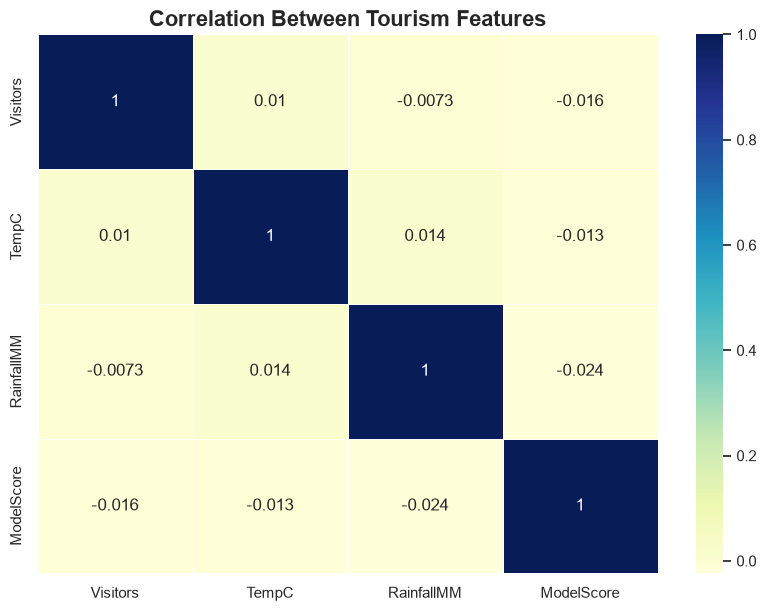

In [ ]:
#correlation heatmap
plt.figure(figsize=(14,6))


numeric_data = data.select_dtypes(
    include=['float64','int64']
)


sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)


plt.title(
    "Correlation Between Tourism Features",
    fontsize=16,
    fontweight="bold"
)


plt.savefig(
    "Tourism_Feature_Correlation.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()